## Performance Impact of Block Reduction Sizes

This notebook benchmarks the performance of a grid computation using various block reduction sizes. The goal is to identify the optimal block size for this hardware configuration.

In this notebook, we apply the workflow to real magnetic data from the Paraná Basin.  
The dataset, provided by ANP, is available through the [CPRM/REATE portal](https://reate.cprm.gov.br/anp/TERRESTRE).

The data can be automatically downloaded within this notebook, where it is also preprocessed.  
As part of the preparation, the sampling rate is reduced from 100 Hz to 1 Hz  
(see `02-parana-basin-data-preparation.ipynb`).

In [1]:
import os
import pygmt
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd
import itertools
from scipy.interpolate import griddata

import spherical as sph

In [2]:
def save_fit_results(model, filename="fit_results"):
    attrs = {}
    for key in ["residuals_", "dipole_moments_", "window_centers_", "source_coordinates_"]:
        if hasattr(model, key):
            attrs[key] = getattr(model, key)
    np.savez(f"{filename}.npz", **attrs, allow_pickle=True)

def load_fit_results(model, filename="fit_results"):
    data = np.load(f"{filename}.npz", allow_pickle=True)
    for key in data.files:
        value = data[key]
        if key == "source_coordinates_":
            value = tuple(value) 
        setattr(model, key, value)
    return model

def deg_to_km(spacing_km):
    spacing_deg = spacing_km / 111.11
    return spacing_deg

First we import the real data.

In [3]:
caminho = "../data/parana-basin-magnetic-processed.csv"

df = pd.read_csv(caminho, sep=',', comment="#")
df.columns = ['FID','ESTACAO','LINHA','X','Y','LATITUDE','LONGITUDE','DATA','HORA','GPSALT','BARO',
              'MAGBRU','MAGCOM','MAGBASE','MAGCOR','MAGNIV','MAGMIC','MAGIGRF','IGRF','MDT']


In [4]:
prefixos = ('19', '29', '39')
df = df[~df['LINHA'].astype(str).str.startswith(prefixos)].copy()

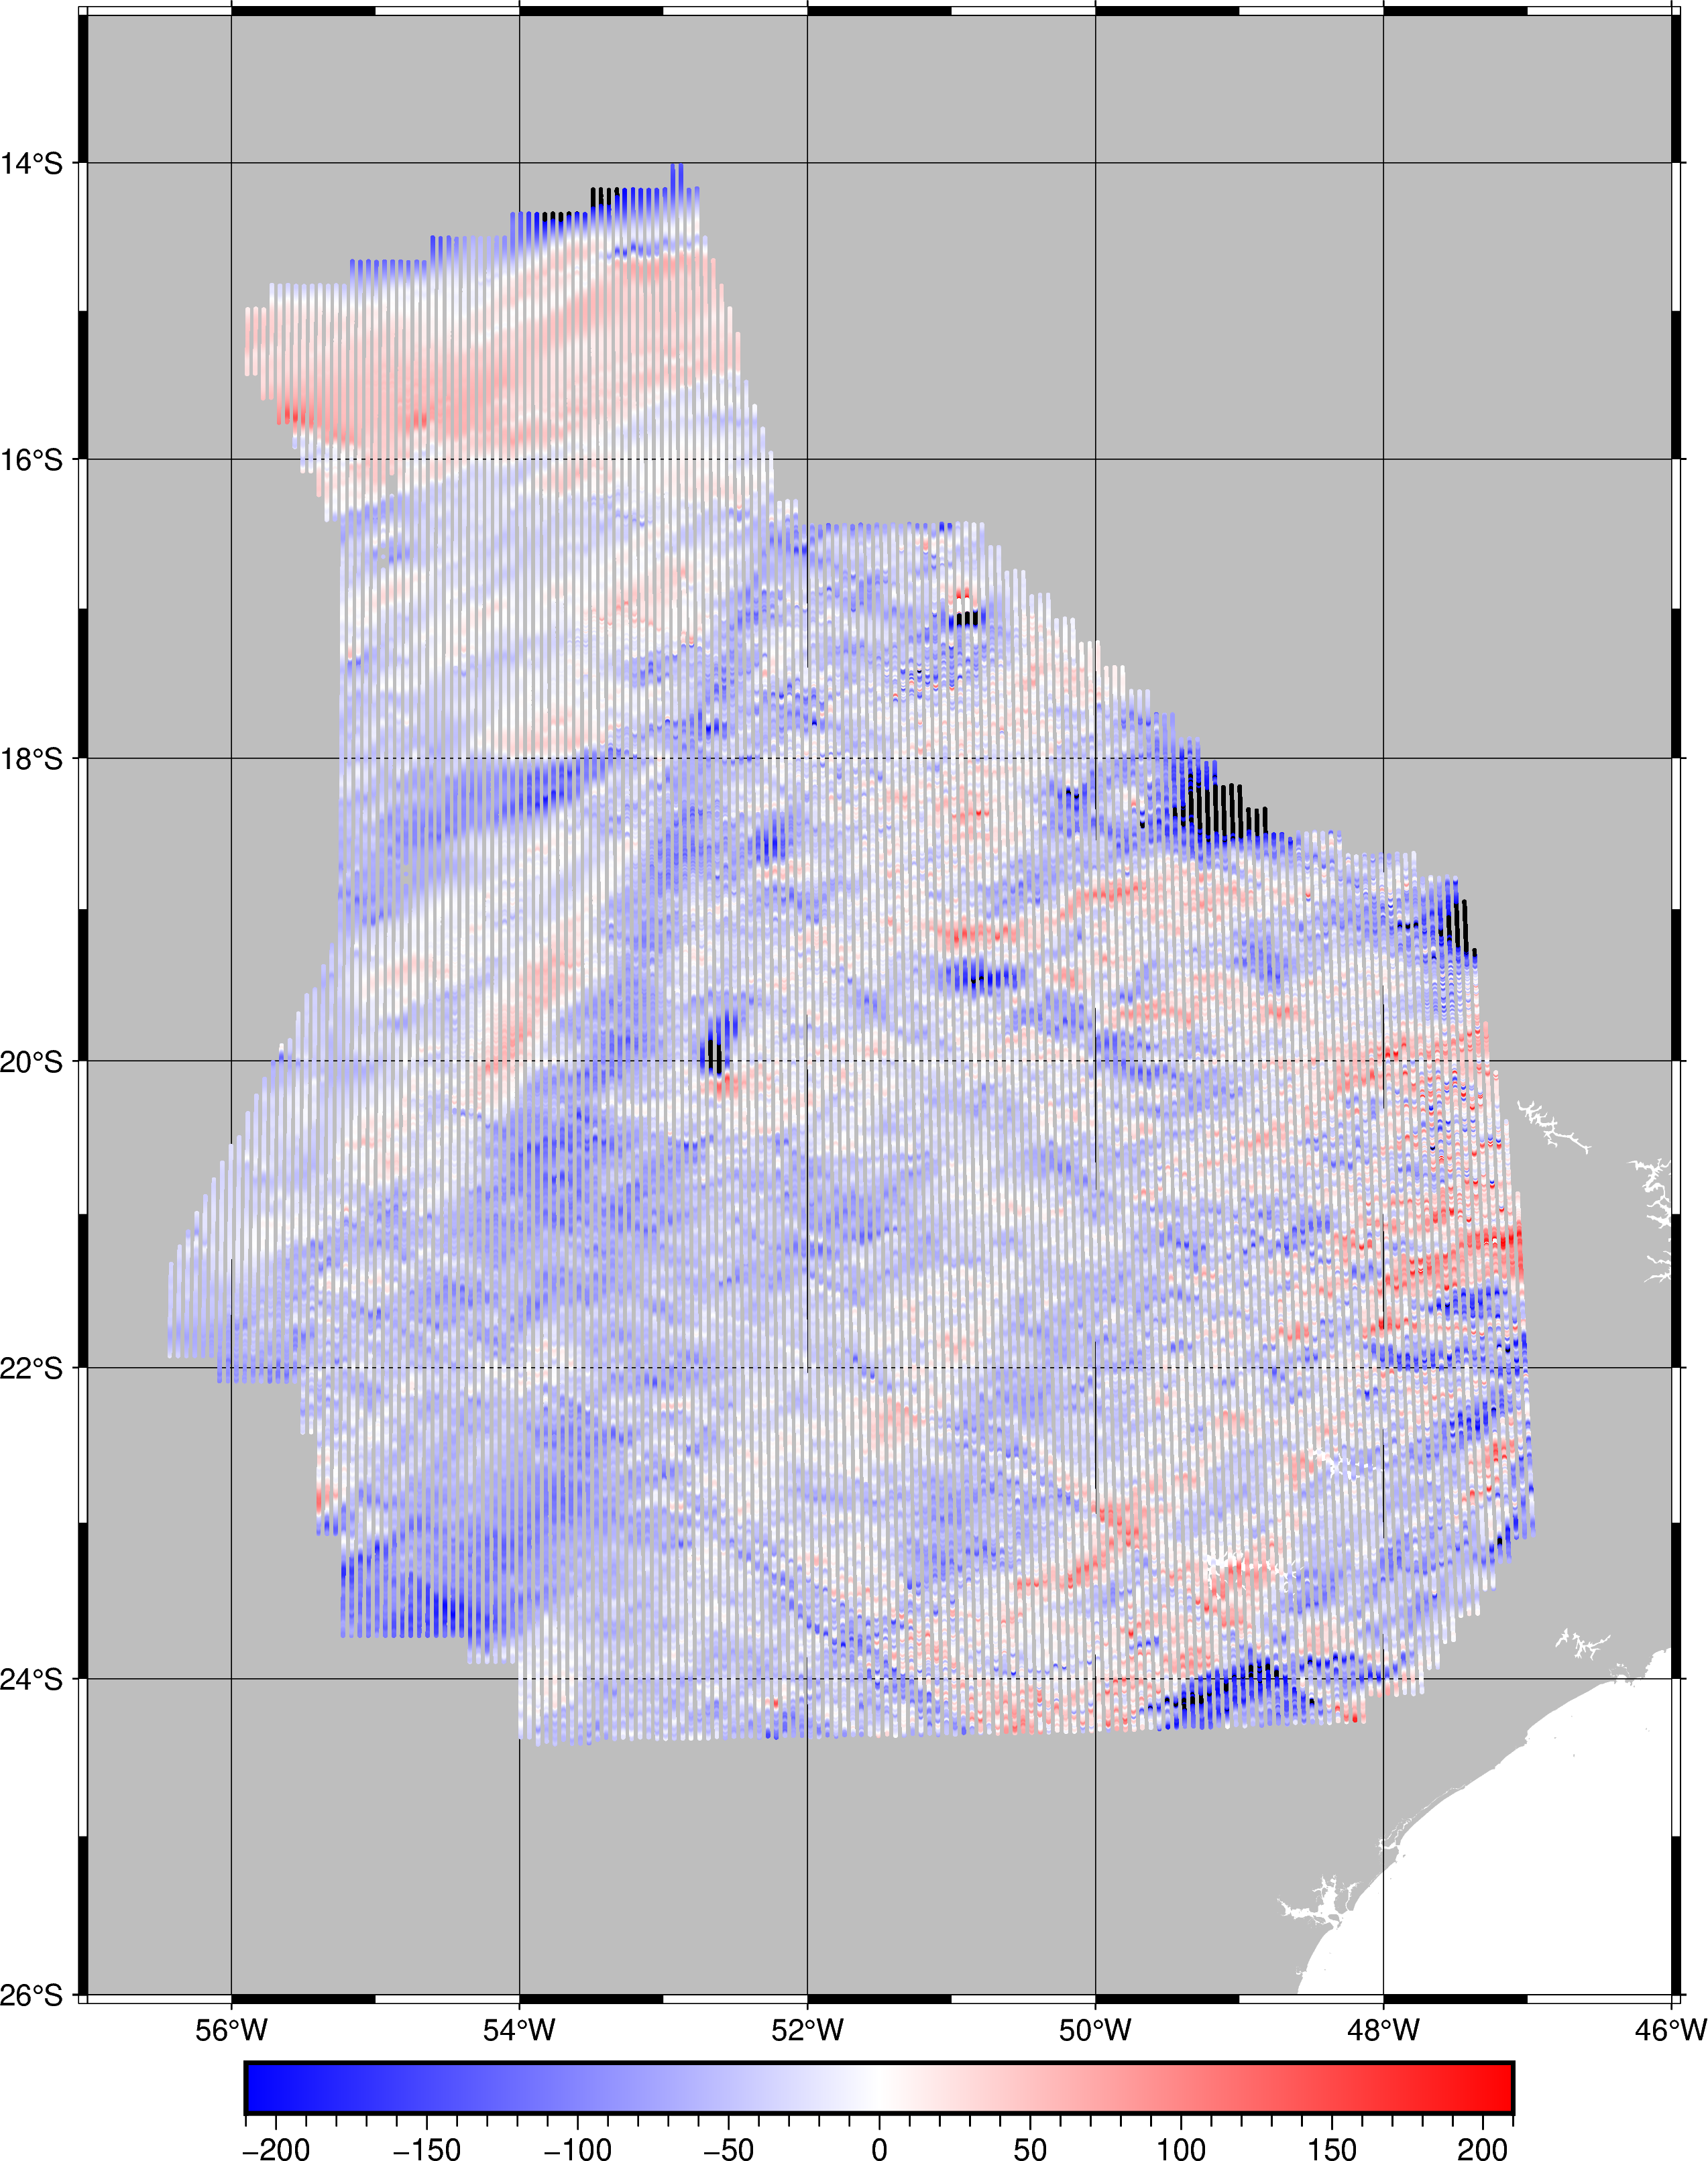

In [5]:
fig = pygmt.Figure()

fig.coast(
    region=[-57, -46, -26, -13],
    projection="M20c", 
    frame="afg",
    land="gray"
)

scale = 210
pygmt.makecpt(cmap="polar+h", series=[-scale, scale])

fig.plot(
    x=df.LONGITUDE,
    y=df.LATITUDE,
    fill=df.MAGIGRF,
    style="c0.05c",
    cmap=True
)

fig.colorbar(position="JBC", frame=True)
fig.show(width=500)

In [6]:
reducer = vd.BlockReduce(reduction=np.median, spacing= 0.01) #bock reduce used = 0.06 ,0.01, 0.0023

coordinates, mag= reducer.filter(
    (df.LONGITUDE, df.LATITUDE, df.GPSALT), df.MAGIGRF
)

coordinates, height = reducer.filter(
    (df.LONGITUDE, df.LATITUDE), df.GPSALT
)

lon, lat = coordinates

coordinates = (lon, lat, height)

# coordinates = (df['LONGITUDE'].values, df['LATITUDE'].values, df["GPSALT"].values)
# mag = (df['MAGIGRF'].values)

print(coordinates[0].size)

/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7fd50c2f1c60> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7fd50c2f1c60> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7fd50c2f1c

## Full Workflow Implementation

Applying the process from notebooks `03` (synthetic data) and `04` (real data).

# Deep equivalent sources

In [7]:
reducer = vd.BlockReduce(reduction=np.mean, spacing=0.1,  center_coordinates=False, drop_coords=False)
blocked_deep_equivalent_sources, magnetic_anomaly_reduced = reducer.filter(coordinates, mag)

print(blocked_deep_equivalent_sources[2].size)

6768


/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function mean at 0x7fd50c3876a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function mean at 0x7fd50c3876a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


In [8]:
inclination, declination = -25, -20 
damping_deep = [1e-1, 1e1, 1e2, 1e3]
source_depth_deep = [70e3,90e3,100e3,110e3] #depths*2.5, depths*4.25, depths*5.75
parameter_sets_deep = [
    dict(damping=combo[0], depth=combo[1])
    for combo in itertools.product(damping_deep, source_depth_deep)
]
print("Number of combinations:", len(parameter_sets_deep))

Number of combinations: 16


In [9]:
%%time
kfold = vd.BlockKFold(
    spacing=0.5,
    shuffle=True,
    random_state=0,
    balance=True,
)
features = np.transpose(blocked_deep_equivalent_sources[:2])
scores_deep = []
damping_deep = []
source_depth_deep = []
for parameters in parameter_sets_deep:    
    print(parameters)
    eqs_deep = sph.EquivalentSourcesMagGeod(**parameters)
    tmp = []
    for train, test in kfold.split(features):
        eqs_deep.fit(
            [c[train] for c in blocked_deep_equivalent_sources],
            inclination, 
            declination,
            magnetic_anomaly_reduced[train] 
        )
        predicted = hm.total_field_anomaly(
            eqs_deep.predict([c[test] for c in blocked_deep_equivalent_sources]),
            inclination, declination
        )
        tmp.append(np.linalg.norm(magnetic_anomaly_reduced[test] - predicted))
    scores_deep.append(np.mean(tmp))
    damping_deep.append(parameters['damping'])
    source_depth_deep.append(parameters['depth'])
best = np.argmin(scores_deep)
parameter_sets_deep[best]

{'damping': 0.1, 'depth': 70000.0}
{'damping': 0.1, 'depth': 90000.0}
{'damping': 0.1, 'depth': 100000.0}
{'damping': 0.1, 'depth': 110000.0}
{'damping': 10.0, 'depth': 70000.0}
{'damping': 10.0, 'depth': 90000.0}
{'damping': 10.0, 'depth': 100000.0}
{'damping': 10.0, 'depth': 110000.0}
{'damping': 100.0, 'depth': 70000.0}
{'damping': 100.0, 'depth': 90000.0}
{'damping': 100.0, 'depth': 100000.0}
{'damping': 100.0, 'depth': 110000.0}
{'damping': 1000.0, 'depth': 70000.0}
{'damping': 1000.0, 'depth': 90000.0}
{'damping': 1000.0, 'depth': 100000.0}
{'damping': 1000.0, 'depth': 110000.0}
CPU times: user 47min 4s, sys: 1min 35s, total: 48min 40s
Wall time: 8min 50s


{'damping': 10.0, 'depth': 100000.0}

Best parameters: {'damping': 10.0, 'depth': 100000.0}
Best RMSE: 1266.359 nT


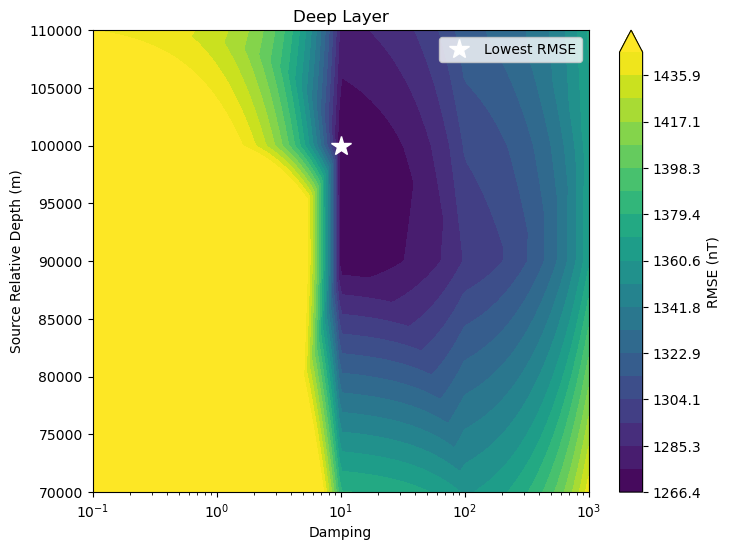

In [10]:
damping_values_deep = np.array(damping_deep)
depth_values_deep = np.array(source_depth_deep)
score_values_deep = np.array(scores_deep)

best_deep = np.argmin(score_values_deep)
best_damping_deep = damping_values_deep[best_deep]
best_depth_deep = depth_values_deep[best_deep]
best_rmse_deep = score_values_deep[best_deep]
best_params_deep = parameter_sets_deep[best_deep]
print("Best parameters:", best_params_deep)
print(f"Best RMSE: {best_rmse_deep:.3f} nT")

x_deep = np.logspace(np.log10(damping_values_deep.min()), np.log10(damping_values_deep.max()), 200)
y_deep = np.linspace(depth_values_deep.min(), depth_values_deep.max(), 200)
X_deep, Y_deep = np.meshgrid(x_deep, y_deep)
Z_deep = griddata(
    (damping_values_deep, depth_values_deep),
    score_values_deep,
    (X_deep, Y_deep),
    method='linear',
)

plt.figure(figsize=(8, 6))
levels_deep = np.linspace(
    Z_deep.min(),
    np.nanpercentile(score_values_deep, 80),
    20,
)
c = plt.contourf(
    X_deep,
    Y_deep,
    Z_deep,
    levels=levels_deep,
    cmap="viridis",
    extend='max',
)
plt.plot(
    best_damping_deep,
    best_depth_deep,
    '*',
    color='white',
    markersize=15,
    label='Lowest RMSE'
)
plt.xscale('log')
plt.xlabel('Damping')
plt.ylabel('Source Relative Depth (m)')
plt.colorbar(c, label='RMSE (nT)')
plt.legend()
plt.title("Deep Layer")
plt.show()

Run the inversion of the deep equivalent sources with the values obtained with the cross-validation.

In [11]:
%%time
eqs_deep = sph.EquivalentSourcesMagGeod(**parameter_sets_deep[best])

eqs_deep.fit(blocked_deep_equivalent_sources, inclination, declination, magnetic_anomaly_reduced)

save_fit_results(eqs_deep, filename="eqs_deep_fit_001")

CPU times: user 57.9 s, sys: 2.57 s, total: 1min
Wall time: 11.7 s


In [12]:
eqs_deep_loaded = sph.EquivalentSourcesMagGeod(**parameter_sets_deep[best])

eqs_deep_loaded = load_fit_results(eqs_deep_loaded, filename="eqs_deep_fit_001")

predicted_deep = hm.total_field_anomaly(
    eqs_deep_loaded.predict(coordinates),
    inclination,
    declination,
)

residuals_deep = mag - predicted_deep 

predicted_blocked_deep = hm.total_field_anomaly(
    eqs_deep_loaded.predict(blocked_deep_equivalent_sources),
    inclination,
    declination,
)

## Cropping Region to Accelerate Cross-Validation

To improve performance, a smaller region is cropped for the shallower layer, which significantly speeds up the cross-validation process.

In [13]:
region_croped = (-54, -50, -18, -16)

cv = bd.inside((coordinates[0], coordinates[1]), region_croped)

lon_cv = coordinates[0][cv]
lat_cv = coordinates[1][cv]
height_cv = coordinates[2][cv]
mag_cv = mag[cv]
residuals_deep_cv = residuals_deep[cv]

coordinates_cv = (lon_cv, lat_cv, height_cv)
print(coordinates_cv[0].size)

12100


Create the grid.

In [14]:
grid_spacing = deg_to_km(1)
window_size = 1.6

grid_coord = bd.grid_coordinates((-56.8, -46.5, -25, -14), spacing= grid_spacing, non_dimensional_coords=500)

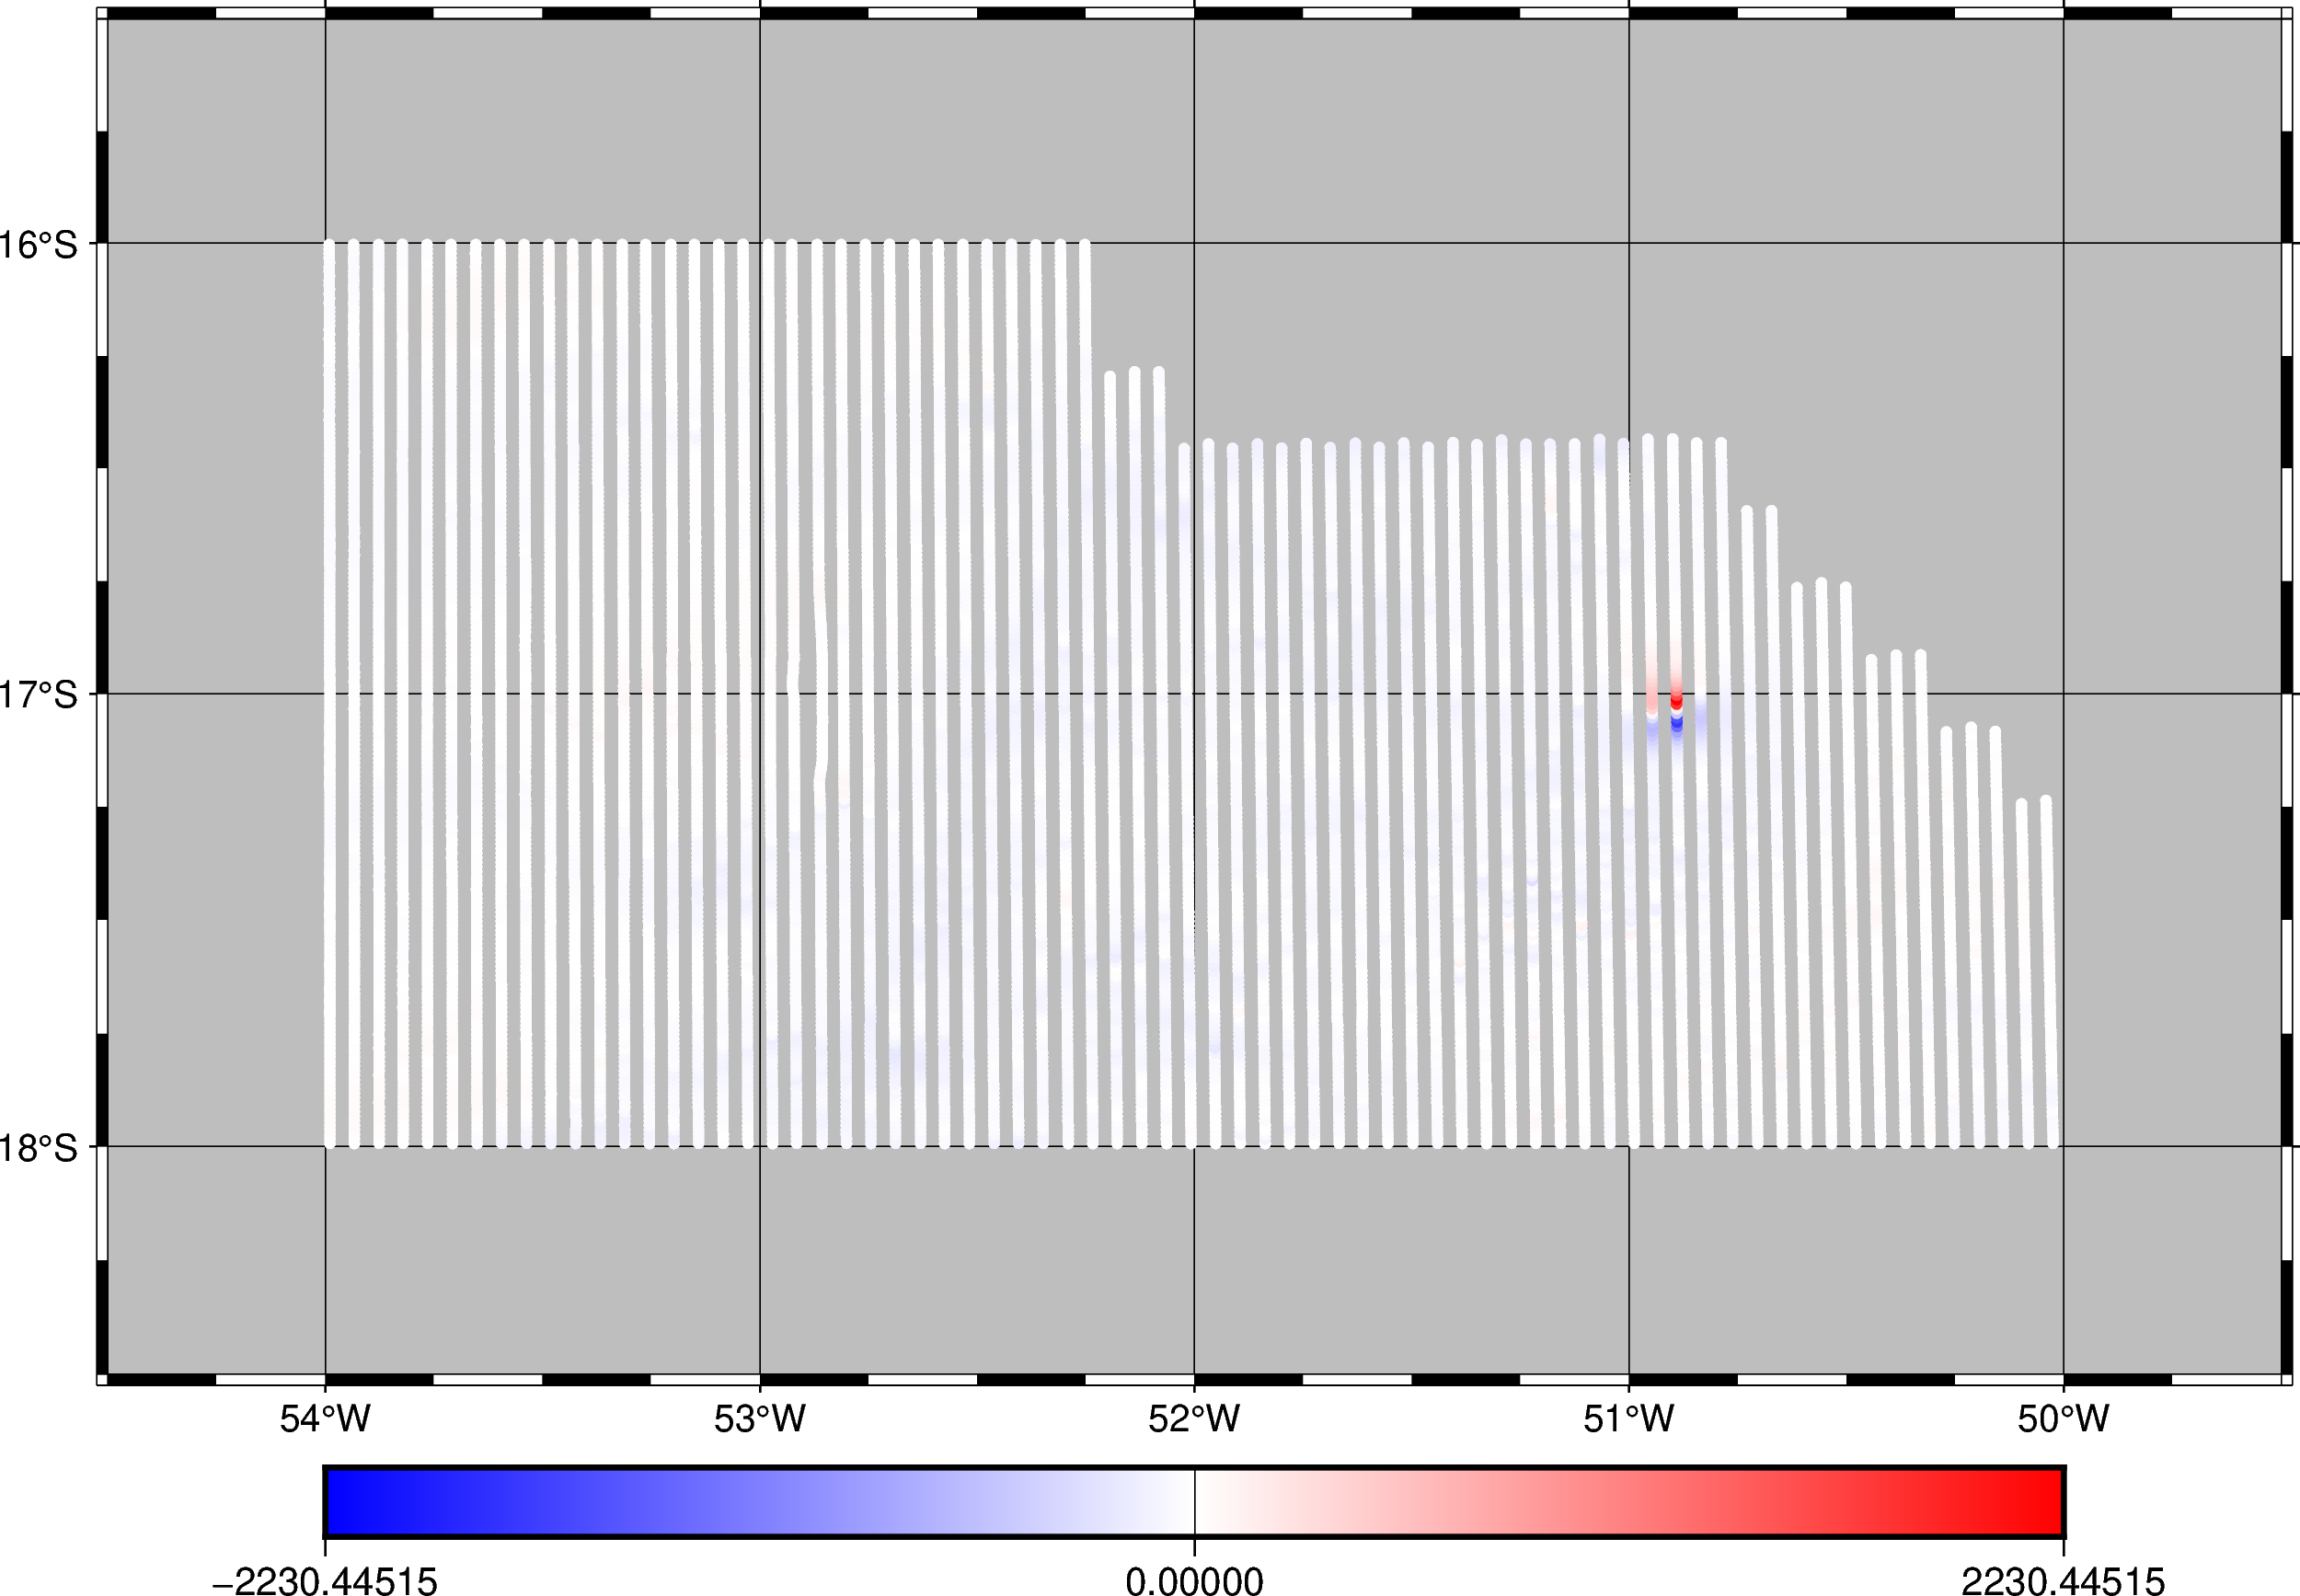

In [15]:
fig = pygmt.Figure()

fig.coast(
    region=[-54.5, -49.5, -18.5, -15.5],
    projection="M20c", 
    frame="afg",
    land="gray"
)

scale = vd.maxabs(mag_cv)
pygmt.makecpt(cmap="polar+h", series=[-scale, scale])

fig.plot(
    x=coordinates_cv[0],
    y=coordinates_cv[1],
    fill=mag_cv,
    style="c0.1c",
    cmap=True
)

fig.colorbar(position="JBC")
fig.show(width=700)

In [16]:
dampings_shallow = [1e0,1e1,1e3,1e5,1e6]
depths_shallow = [3e3, 5e3,7e3,9e3] 
parameter_sets_shallow = [
    dict(damping=combo[0], depth=combo[1])
    for combo in itertools.product(dampings_shallow, depths_shallow)
] 
print("Number of combinations:", len(parameter_sets_shallow))

Number of combinations: 25


In [17]:
%%time
kfold = vd.BlockKFold(
    spacing=deg_to_km(15),
    shuffle=True,
    random_state=0,
    balance=True,
)
features = np.transpose(coordinates_cv[:2])
scores_shallow = []
damping_shallow = []
source_depth_shallow = []
for parameters in parameter_sets_shallow:    
    print(parameters)
    eqs_shallow = sph.EquivalentSourcesMagGeodGB(block_size=grid_spacing, window_size=0.5,verbose=False,**parameters)
    tmp = []
    for train, test in kfold.split(features):
        eqs_shallow.fit(
            [c[train] for c in coordinates_cv],  
            inclination,declination,
            residuals_deep_cv[train],
        )
        predicted = hm.total_field_anomaly(
            eqs_shallow.predict([c[test] for c in coordinates_cv]),
            inclination,declination,
        )
        tmp.append(np.linalg.norm(residuals_deep_cv[test] - predicted))
    scores_shallow.append(np.mean(tmp))
    damping_shallow.append(parameters['damping'])
    source_depth_shallow.append(parameters['depth'])
best = np.argmin(scores_shallow)
parameter_sets_shallow[best]

{'damping': 1.0, 'depth': 5000.0}
{'damping': 1.0, 'depth': 7000.0}
{'damping': 1.0, 'depth': 9000.0}
{'damping': 1.0, 'depth': 11000.0}
{'damping': 1.0, 'depth': 15000.0}
{'damping': 10.0, 'depth': 5000.0}
{'damping': 10.0, 'depth': 7000.0}
{'damping': 10.0, 'depth': 9000.0}
{'damping': 10.0, 'depth': 11000.0}
{'damping': 10.0, 'depth': 15000.0}
{'damping': 1000.0, 'depth': 5000.0}
{'damping': 1000.0, 'depth': 7000.0}
{'damping': 1000.0, 'depth': 9000.0}
{'damping': 1000.0, 'depth': 11000.0}
{'damping': 1000.0, 'depth': 15000.0}
{'damping': 100000.0, 'depth': 5000.0}
{'damping': 100000.0, 'depth': 7000.0}
{'damping': 100000.0, 'depth': 9000.0}
{'damping': 100000.0, 'depth': 11000.0}
{'damping': 100000.0, 'depth': 15000.0}
{'damping': 1000000.0, 'depth': 5000.0}
{'damping': 1000000.0, 'depth': 7000.0}
{'damping': 1000000.0, 'depth': 9000.0}
{'damping': 1000000.0, 'depth': 11000.0}
{'damping': 1000000.0, 'depth': 15000.0}
CPU times: user 3h 9min 8s, sys: 18.5 s, total: 3h 9min 27s
Wall 

{'damping': 1000.0, 'depth': 5000.0}

Best parameters: {'damping': 1000.0, 'depth': 5000.0}
Best RMSE: 1882.425 nT


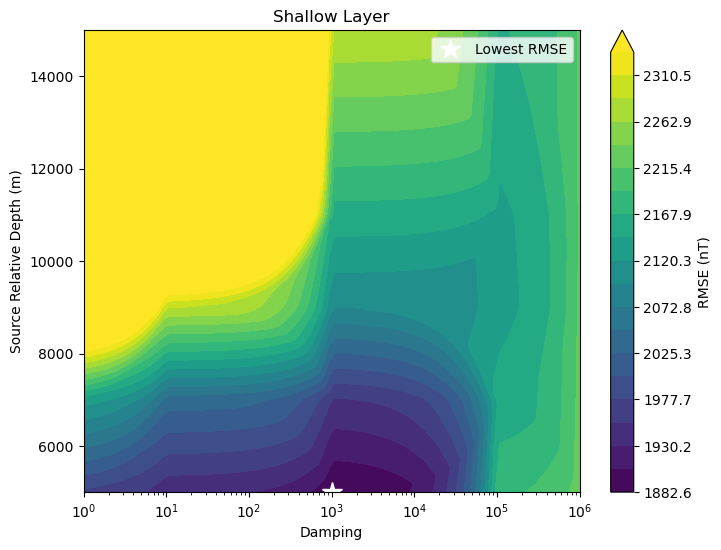

In [18]:
damping_values_shallow = np.array(damping_shallow)
depth_values_shallow = np.array(source_depth_shallow)
score_values_shallow = np.array(scores_shallow)

best_shallow = np.argmin(score_values_shallow)
best_damping_shallow = damping_values_shallow[best_shallow]
best_depth_shallow = depth_values_shallow[best_shallow]
best_rmse_shallow = score_values_shallow[best_shallow]
best_params_shallow = parameter_sets_shallow[best_shallow]
print("Best parameters:", best_params_shallow)
print(f"Best RMSE: {best_rmse_shallow:.3f} nT")

x_shallow = np.logspace(np.log10(damping_values_shallow.min()), np.log10(damping_values_shallow.max()), 100)
y_shallow = np.linspace(depth_values_shallow.min(), depth_values_shallow.max(), 100)
X_shallow, Y_shallow = np.meshgrid(x_shallow, y_shallow)

Z_shallow = griddata(
    (damping_values_shallow, depth_values_shallow),
    score_values_shallow,
    (X_shallow, Y_shallow),
    method='linear'
)
plt.figure(figsize=(8, 6))
levels_shallow = np.linspace(
    Z_shallow.min(),
    np.nanpercentile(score_values_shallow, 80),
    20,
)
c = plt.contourf(
    X_shallow,
    Y_shallow,
    Z_shallow,
    levels=levels_shallow,
    cmap="viridis",
    extend='max',
)
plt.plot(
    best_damping_shallow,
    best_depth_shallow,
    '*',
    color='white',
    markersize=15,
    label='Lowest RMSE'
)
plt.xscale('log')
plt.xlabel('Damping')
plt.ylabel('Source Relative Depth (m)')
plt.colorbar(c, label='RMSE (nT)')
plt.legend()
plt.title("Shallow Layer")
plt.show()

In [19]:
%%time
eqs_shallow = sph.EquivalentSourcesMagGeodGB(
    block_size=grid_spacing,
    window_size=window_size,
    **parameter_sets_shallow[best]
)


eqs_shallow.fit(coordinates, inclination, declination, residuals_deep)


Output()

CPU times: user 2h 22min 34s, sys: 1min 27s, total: 2h 24min 2s

Wall time: 21min 43s

KeyboardInterrupt: 

In [ ]:
save_fit_results(eqs_shallow, filename="eqs_shallow_fit_001")

In [ ]:
# %%time
# total_field_anomaly_predicted = vd.make_xarray_grid(
#     grid_coord,
#     hm.total_field_anomaly(eqs_deep.predict(grid_coord), inclination, declination),
#     data_names="grid",
#     dims=("latitude", "longitude"),
#     extra_coords_names="height",
# ).grid

In [ ]:
# %%time
# total_field_anomaly_predicted += vd.make_xarray_grid(
#     grid_coord,
#     hm.total_field_anomaly(eqs_shallow.predict(grid_coord), inclination, declination),
#     data_names="grid",
#     dims=("latitude", "longitude"),
#     extra_coords_names="height",
# ).grid

In [ ]:
# shapefile_brasil = "../../../.cache/pooch//BR_UF_2022/BR_UF_2022.shp"


# required_extensions = ['.shp', '.shx', '.dbf']
# base_name = os.path.splitext(shapefile_brasil)[0]

# missing_files = []
# for ext in required_extensions:
#     file_path = f"{base_name}{ext}"
#     if not os.path.exists(file_path):
#         missing_files.append(file_path)

# if missing_files:
#     print(f"Erro: Os seguintes arquivos obrigatórios estão faltando: {', '.join(missing_files)}")
#     exit()


# try:
#     brasil = gpd.read_file(shapefile_brasil)
# except Exception as e:
#     print(f"Erro ao carregar o shapefile: {e}")
#     exit()



# brasil_reduc = brasil.simplify(0.05)

In [ ]:
# tfa_scatter = predicted_deep + predicted_shallow


# region = [-56.8, -46.5, -25, -14]
# scale = 220
# fig = pygmt.Figure()

# with pygmt.config(FONT="10p,Palatino-Roman",
#     FONT_ANNOT="8p,Palatino-Roman",
#     FONT_ANNOT_PRIMARY="8p,Palatino-Roman",
#     FONT_ANNOT_SECONDARY="8p,Palatino-Roman",
#     MAP_FRAME_WIDTH="1.5p",
#     MAP_TITLE_OFFSET="-2p", ):

#     pygmt.makecpt(cmap="polar", series=[-scale, scale])

#     with fig.subplot(nrows=1,
#             ncols=3,
#             figsize=("16c", "6c"),
#             autolabel="+jTL+o0.1/0.3c",
#             margins='0.2c/.2c',
#             sharex="b",
#             sharey="l"):
        
#         with fig.set_panel(panel=0):

#             fig.coast(
#                     land="#888888",
#                     region = region,
#                     projection="M?",
#                 )

#             fig.plot(
#                     x=df.LONGITUDE,
#                     y=df.LATITUDE,
#                     fill=df.MAGIGRF,
#                     style="c0.01c",
#                     cmap=True
#             )

#             fig.plot(
#                 data=brasil_reduc.geometry,
#                 pen=".2p,white",
#                 fill=None,
#                 projection="M?",
#                 frame=["a42f"]
#             )


#         with fig.set_panel(panel=1):

#             fig.coast(
#                     land="#888888",
#                     region = region,
#                     projection="M?",
#             )
            
#             fig.plot(
#                 x=coordinates[0],
#                 y=coordinates[1],
#                 fill=tfa_scatter,
#                 style="c0.01c",
#                 projection="M?",
#                 cmap=True
#             )

#             fig.plot(
#                 data=brasil_reduc.geometry,
#                 pen=".2p,white",
#                 fill=None,
#                 projection="M?",
#                 frame=["a42f"]
#             )

#         with fig.set_panel(panel=2):

#             fig.coast(
#                 land="#888888",
#                 region = region,
#                 projection="M?",
#             )

#             fig.grdimage(
#             grid=total_field_anomaly_predicted,
#             region=region,
#             projection="M?",  
#             cmap=True,
#             shading="+nt0.15",
#             )       

#             fig.plot(
#                 data=brasil_reduc.geometry,
#                 pen=".2p,white",
#                 fill=None,
#                 projection="M?",
#                 frame=["a42f"]
#             )


# pygmt.config(FONT_ANNOT_PRIMARY="10p,Palatino-Roman", FONT_ANNOT_SECONDARY="10p,Palatino-Roman")
# fig.colorbar(position="JBC+w8/0.2c+h", frame=["y+lnT", 'a'])
# fig.show(width=7000)
# fig.savefig(fname='../paper/figures/comparison-blocreduce-fulldata.jpeg',transparent=False)